<a href="https://colab.research.google.com/github/imanalhusryah-arch/microscope-image/blob/main/super%20resolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

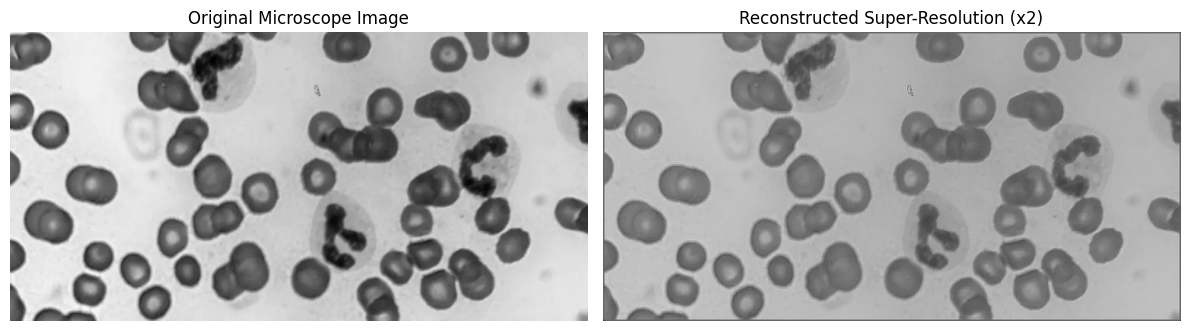

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import restoration, img_as_float

# 1. تحميل الصورة المجهرية وقراءتها بصيغة الرمادي (Grayscale) لأن خوارزميات التفكيك تعمل بشكل أفضل عليها
# (يمكن تطبيقها على القنوات اللونية بشكل منفصل إذا كانت الصورة ملونة)
image_path = '/content/microscpe.png.webp'  # ضعي مسار صورتك هنا
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# تحويل الصورة إلى قيم عشرية بين 0 و 1 (مهم جداً للحسابات الرياضية الدقيقة)
img_float = img_as_float(img)

# 2. محاكاة دالة التشتت الضوئي للمجهر (PSF)
# كلاسيكياً، يتم تمثيل تشتت الضوء في عدسات المجهر باستخدام مرشح غاوسي (Gaussian kernel)
psf_size = 5
psf = np.outer(cv2.getGaussianKernel(psf_size, 1), cv2.getGaussianKernel(psf_size, 1))

# 3. تطبيق تقنية إعادة البناء الكلاسيكية (Richardson-Lucy Deconvolution)
# عدد التكرارات (iterations) يتحكم في درجة حدة التفاصيل؛ البدء بـ 30 يعد خياراً جيداً لصور العينات
deconvolved_img = restoration.richardson_lucy(img_float, psf, num_iter=30)

# 4. تكبير الصورة الناتجة للحصول على الدقة الفائقة (Super-Resolution) باستخدام الاستيفاء التكعيبي
# لضمان الحفاظ على الحواف الحادة المعاد بناؤها
scale_factor = 2  # معامل التكبير (مثلاً x2)
width = int(deconvolved_img.shape[1] * scale_factor)
height = int(deconvolved_img.shape[0] * scale_factor)

high_res_img = cv2.resize(deconvolved_img, (width, height), interpolation=cv2.INTER_CUBIC)

# 5. عرض ومقارنة النتائج
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Microscope Image")
plt.imshow(img_float, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Super-Resolution (x2)")
plt.imshow(high_res_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

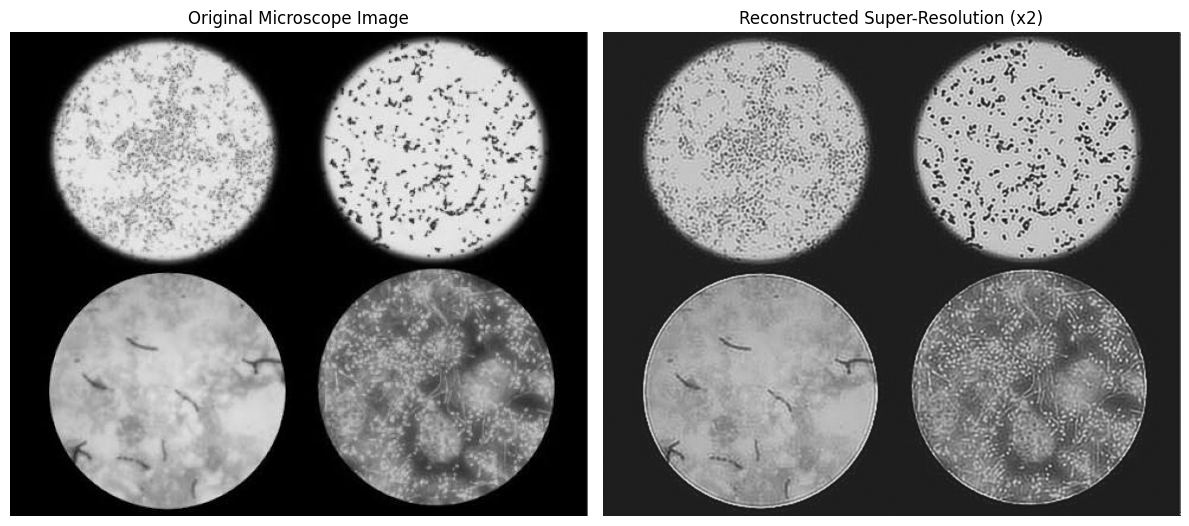

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import restoration, img_as_float

# 1. تحميل الصورة المجهرية وقراءتها بصيغة الرمادي (Grayscale) لأن خوارزميات التفكيك تعمل بشكل أفضل عليها
# (يمكن تطبيقها على القنوات اللونية بشكل منفصل إذا كانت الصورة ملونة)
image_path = '/content/images.jfif'  # ضعي مسار صورتك هنا
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# تحويل الصورة إلى قيم عشرية بين 0 و 1 (مهم جداً للحسابات الرياضية الدقيقة)
img_float = img_as_float(img)

# 2. محاكاة دالة التشتت الضوئي للمجهر (PSF)
# كلاسيكياً، يتم تمثيل تشتت الضوء في عدسات المجهر باستخدام مرشح غاوسي (Gaussian kernel)
psf_size = 5
psf = np.outer(cv2.getGaussianKernel(psf_size, 1), cv2.getGaussianKernel(psf_size, 1))

# 3. تطبيق تقنية إعادة البناء الكلاسيكية (Richardson-Lucy Deconvolution)
# عدد التكرارات (iterations) يتحكم في درجة حدة التفاصيل؛ البدء بـ 30 يعد خياراً جيداً لصور العينات
deconvolved_img = restoration.richardson_lucy(img_float, psf, num_iter=30)

# 4. تكبير الصورة الناتجة للحصول على الدقة الفائقة (Super-Resolution) باستخدام الاستيفاء التكعيبي
# لضمان الحفاظ على الحواف الحادة المعاد بناؤها
scale_factor = 2  # معامل التكبير (مثلاً x2)
width = int(deconvolved_img.shape[1] * scale_factor)
height = int(deconvolved_img.shape[0] * scale_factor)

high_res_img = cv2.resize(deconvolved_img, (width, height), interpolation=cv2.INTER_CUBIC)

# 5. عرض ومقارنة النتائج
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Microscope Image")
plt.imshow(img_float, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Super-Resolution (x2)")
plt.imshow(high_res_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

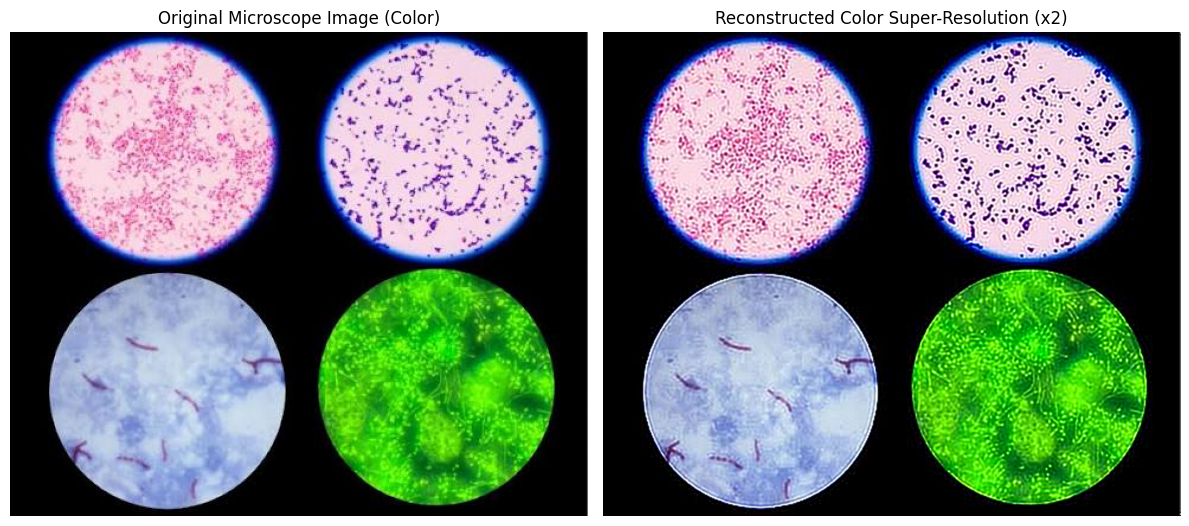

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import restoration, img_as_float

# 1. تحميل الصورة المجهرية الملونة
# ضعي هنا المسار الصحيح تماماً لملفكِ
image_path = '/content/images.jfif'
img_bgr = cv2.imread(image_path)

# شرط الأمان للتحقق من تحميل الصورة
if img_bgr is None:
    raise FileNotFoundError(f"لم يتم العثور على الصورة في المسار المحدد: {image_path}. تأكدي من رفعها ونسخ مسارها بشكل صحيح.")

# تحويل الصورة من BGR (نظام OpenCV الافتراضي) إلى RGB للحفاظ على الألوان الحقيقية عند العرض
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_float = img_as_float(img_rgb)

# 2. محاكاة دالة التشتت الضوئي للمجهر (PSF)
psf_size = 5
psf = np.outer(cv2.getGaussianKernel(psf_size, 1), cv2.getGaussianKernel(psf_size, 1))

# 3. تطبيق تقنية إعادة البناء (Richardson-Lucy) على القنوات اللونية الثلاث بشكل منفصل
reconstructed_channels = []
for i in range(3):  # المرور على القنوات: الأحمر، الأخضر، الأزرق
    channel = img_float[:, :, i]
    deconvolved_channel = restoration.richardson_lucy(channel, psf, num_iter=30)
    reconstructed_channels.append(deconvolved_channel)

# دمج القنوات المعاد بناؤها في صورة ملونة واحدة
img_deconvolved = np.stack(reconstructed_channels, axis=-1)

# 4. تكبير الصورة الناتجة للحصول على الدقة الفائقة (Super-Resolution)
scale_factor = 2  # معامل التكبير
width = int(img_deconvolved.shape[1] * scale_factor)
height = int(img_deconvolved.shape[0] * scale_factor)

high_res_img = cv2.resize(img_deconvolved, (width, height), interpolation=cv2.INTER_CUBIC)

# لضمان عدم خروج قيم الألوان عن النطاق المسموح به [0, 1] بعد التكبير والاستيفاء
high_res_img = np.clip(high_res_img, 0, 1)

# 5. عرض ومقارنة النتائج بالألوان الأساسية
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Microscope Image (Color)")
plt.imshow(img_float)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Color Super-Resolution (x2)")
plt.imshow(high_res_img)
plt.axis('off')

plt.tight_layout()
plt.show()

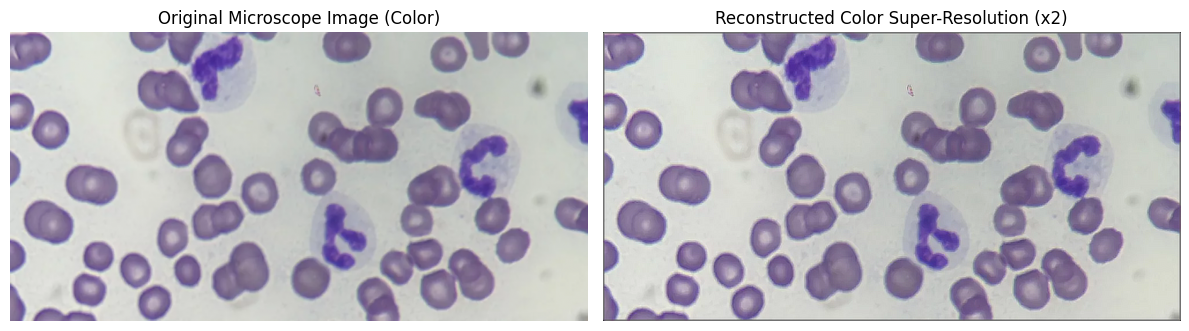

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import restoration, img_as_float

# 1. تحميل الصورة المجهرية الملونة
# ضعي هنا المسار الصحيح تماماً لملفكِ
image_path = '/content/microscpe.png.webp'
img_bgr = cv2.imread(image_path)

# شرط الأمان للتحقق من تحميل الصورة
if img_bgr is None:
    raise FileNotFoundError(f"لم يتم العثور على الصورة في المسار المحدد: {image_path}. تأكدي من رفعها ونسخ مسارها بشكل صحيح.")

# تحويل الصورة من BGR (نظام OpenCV الافتراضي) إلى RGB للحفاظ على الألوان الحقيقية عند العرض
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_float = img_as_float(img_rgb)

# 2. محاكاة دالة التشتت الضوئي للمجهر (PSF)
psf_size = 5
psf = np.outer(cv2.getGaussianKernel(psf_size, 1), cv2.getGaussianKernel(psf_size, 1))

# 3. تطبيق تقنية إعادة البناء (Richardson-Lucy) على القنوات اللونية الثلاث بشكل منفصل
reconstructed_channels = []
for i in range(3):  # المرور على القنوات: الأحمر، الأخضر، الأزرق
    channel = img_float[:, :, i]
    deconvolved_channel = restoration.richardson_lucy(channel, psf, num_iter=30)
    reconstructed_channels.append(deconvolved_channel)

# دمج القنوات المعاد بناؤها في صورة ملونة واحدة
img_deconvolved = np.stack(reconstructed_channels, axis=-1)

# 4. تكبير الصورة الناتجة للحصول على الدقة الفائقة (Super-Resolution)
scale_factor = 2  # معامل التكبير
width = int(img_deconvolved.shape[1] * scale_factor)
height = int(img_deconvolved.shape[0] * scale_factor)

high_res_img = cv2.resize(img_deconvolved, (width, height), interpolation=cv2.INTER_CUBIC)

# لضمان عدم خروج قيم الألوان عن النطاق المسموح به [0, 1] بعد التكبير والاستيفاء
high_res_img = np.clip(high_res_img, 0, 1)

# 5. عرض ومقارنة النتائج بالألوان الأساسية
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Microscope Image (Color)")
plt.imshow(img_float)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Color Super-Resolution (x2)")
plt.imshow(high_res_img)
plt.axis('off')

plt.tight_layout()
plt.show()